11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train shape: (60000, 28, 28)
Test shape: (10000, 28, 28)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,730 (49.73 KB)

 Trainable params: 12,730 (49.73 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.7200 - loss: 1.2536 - val_accuracy: 0.9035 - val_loss: 0.4002
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9067 - loss: 0.3696 - val_accuracy: 0.9199 - val_loss: 0.2917
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9223 - loss: 0.2827 - val_accuracy: 0.9278 - val_loss: 0.2553
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9308 - loss: 0.2465 - val_accuracy: 0.9320 - val_loss: 0.2352
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9379 - loss: 0.2237 - val_accuracy: 0.9362 - val_loss: 0.2226
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9408 - loss: 0.2095 - val_accuracy: 0.9382 - val_loss: 0.2124
Epoch 7/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9432 - loss: 0.1995 - val_accuracy: 0.9402 - val_loss: 0.2057
Epoch 8/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9459 - loss: 0.1924 - 

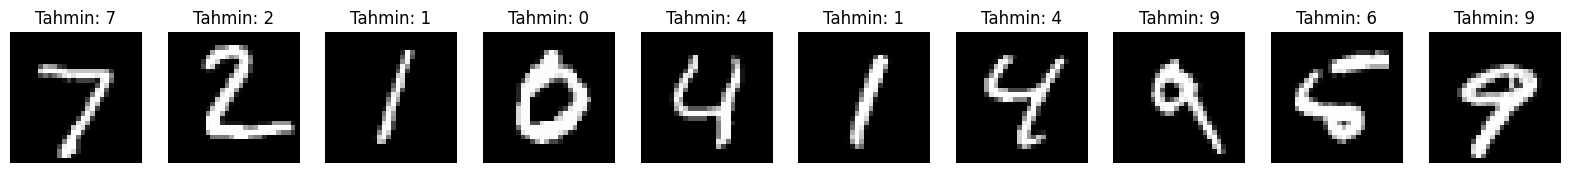

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from keras.layers import Dense, Flatten
from keras.models import Sequential
from tensorflow.keras.utils import to_categorical
from keras.datasets import mnist

# ===============================
# 1. VERİYİ YÜKLE
# ===============================
(X_train, y_train), (X_test, y_test) = mnist.load_data()

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# ===============================
# 2. NORMALIZATION
# ===============================
X_train = X_train / 255.0
X_test  = X_test / 255.0

# ===============================
# 3. ONE-HOT ENCODING
# ===============================
y_train = to_categorical(y_train, num_classes=10)
y_test  = to_categorical(y_test, num_classes=10)

# ===============================
# 4. MODEL OLUŞTUR
# ===============================
model = Sequential()
model.add(Flatten(input_shape=(28,28)))
model.add(Dense(16, activation='sigmoid'))
model.add(Dense(10, activation='softmax'))

model.summary()

# ===============================
# 5. DERLE
# ===============================
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# ===============================
# 6. EĞİT
# ===============================
model.fit(
    X_train,
    y_train,
    epochs=15,
    validation_data=(X_test, y_test)
)

# ===============================
# 7. TAHMİN
# ===============================
predictions = model.predict(X_test)
predictions = np.argmax(predictions, axis=1)

# ===============================
# 8. GÖRSELLEŞTİRME
# ===============================
fig, axes = plt.subplots(1, 10, figsize=(20,4))
for i in range(10):
    axes[i].imshow(X_test[i], cmap='gray')
    axes[i].set_title(f"Tahmin: {predictions[i]}")
    axes[i].axis('off')

plt.show()
